In [9]:
import pandas as pd # type: ignore
import numpy as np
import matplotlib as plt  # type: ignore
import seaborn as sns # type: ignore
from sklearn.model_selection import train_test_split, GridSearchCV # type: ignore
from sklearn.metrics import mean_squared_error, r2_score # type: ignore
import os
import joblib # type: ignore
from sklearn.linear_model import Lasso

In [10]:
dr = pd.read_excel('descriptors.xlsx')
del dr['ID']
dr.head()


,smiles,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289


In [11]:
df = pd.read_csv("Morgan.csv")
del df['ID']
df.head()

,smiles,morgan_fingerprint
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...


In [12]:
def split_bits(row):
    if pd.isna(row['morgan_fingerprint']):
        return pd.Series([np.nan] * 1024)
    else:
        return pd.Series(list(row['morgan_fingerprint']))

bit_columns = df.apply(split_bits, axis=1)

bit_columns.columns = [f'F_{i+1}' for i in range(bit_columns.shape[1])]
final_df = pd.concat([df.reset_index(drop=True), bit_columns], axis=1)
final_df.head()

,smiles,morgan_fingerprint,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,...,F_1015,F_1016,F_1017,F_1018,F_1019,F_1020,F_1021,F_1022,F_1023,F_1024
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...,0,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...,0,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [13]:
final_df = final_df.dropna()

y1 = dr[dr['smiles'].isin(final_df['smiles'])]

In [14]:
input = final_df.copy()
del input['morgan_fingerprint']
del input['smiles']
input.head()

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,F_10,...,F_1015,F_1016,F_1017,F_1018,F_1019,F_1020,F_1021,F_1022,F_1023,F_1024
0,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [15]:
del y1['smiles']

In [16]:
for column in input.columns:
    if input[column].dtype == 'object':
        input[column] = pd.to_numeric(input[column], errors='coerce')

# Check the new data types
print(input.dtypes)

F_1       int64
F_2       int64
F_3       int64
F_4       int64
F_5       int64
          ...  
F_1020    int64
F_1021    int64
F_1022    int64
F_1023    int64
F_1024    int64
Length: 1024, dtype: object


In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [18]:
n_components = 5

abb = y1

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(abb)

#pca = PCA(n_components=n_components)
#X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA-transformed data
#pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])

# Save the PCA-transformed data to a new CSV file
#pca_df.to_csv('pca.csv', index=False)

print("PCA transformation complete. Transformed data saved to 'pca.csv'.")


PCA transformation complete. Transformed data saved to 'pca.csv'.


In [13]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import optuna
import gpflow


In [ ]:
pip install gpflow


In [15]:
import os
import logging
import numpy as np
import pandas as pd
import joblib
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score




GAUSSIAN PROCESS REGRESSION

In [3]:
import os
import logging
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import optuna
import joblib

In [4]:
from sklearn.model_selection import KFold


In [ ]:
# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Assume X and Y are already defined
X = input  # Replace with your actual data
Y = abb.copy()
results_list = []
model_dir = 'models_gpf_bayes_val_cv'
os.makedirs(model_dir, exist_ok=True)

def objective(trial, X_train, y_train):
    kernel_length_scale = trial.suggest_float('kernel_length_scale', 1e-2, 1e2, log=True)
    kernel_variance = trial.suggest_float('kernel_variance', 1e-2, 1e2, log=True)

    # Define the kernel
    kernel = gpflow.kernels.SquaredExponential(lengthscales=kernel_length_scale, variance=kernel_variance)

    # Convert X_train and y_train to NumPy arrays
    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)

    # Initialize the GPR model
    model = gpflow.models.GPR(data=(X_train_np, y_train_np.reshape(-1, 1)), kernel=kernel)

    # Perform manual cross-validation
    kf = KFold(n_splits=5)
    cv_mae_list = []

    for train_index, val_index in kf.split(X_train_np):
        X_train_fold, X_val_fold = X_train_np[train_index], X_train_np[val_index]
        y_train_fold, y_val_fold = y_train_np[train_index], y_train_np[val_index]

        # Create a new model for each fold
        model_fold = gpflow.models.GPR(data=(X_train_fold, y_train_fold.reshape(-1, 1)), kernel=kernel)

        # Fit the model
        gpflow.optimizers.Scipy().minimize(model_fold.training_loss, model_fold.trainable_variables, method='L-BFGS-B')

        # Predict and compute the MAE for validation
        y_val_pred, _ = model_fold.predict_f(X_val_fold)
        cv_mae = mean_absolute_error(y_val_fold, y_val_pred.numpy())
        cv_mae_list.append(cv_mae)

    # Return the average MAE across folds
    return np.mean(cv_mae_list)



for feature in Y.columns:
    model_path = os.path.join(model_dir, f'model_{feature}.pkl')

    # Skip if model already exists
    if os.path.exists(model_path):
        logging.info(f"Model for feature '{feature}' already exists, skipping...")
        continue

    y = Y[feature].to_numpy()  # Convert y to a NumPy array
    
    # Split the data into train and validation sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    # Ensure types are correct
    X_train = X_train.astype(np.float64)
    y_train = y_train.astype(np.float64)

    # Log shapes
    logging.info("Shapes for feature '%s': X_train: %s, y_train: %s", feature, X_train.shape, y_train.shape)

    # Create a study for Bayesian optimization
    study = optuna.create_study(direction='minimize')  # Minimize MAE
    try:
        study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=10)
    except Exception as e:
        logging.error(f"Error during optimization for feature '{feature}': {e}")
        continue
    
    best_params = study.best_params

    # Define the best kernel using optimized parameters
    best_kernel = gpflow.kernels.SquaredExponential(lengthscales=best_params['kernel_length_scale'], variance=best_params['kernel_variance'])

    # Create the best model with optimized parameters
    best_model = gpflow.models.GPR(data=(X_train, y_train.reshape(-1, 1)), kernel=best_kernel)
    
    # After fitting the best model
    try:
        # Ensure X_val and X_test are NumPy arrays of type float64
        X_val_np = np.array(X_val, dtype=np.float64)
        X_test_np = np.array(X_test, dtype=np.float64)
    
        # Predict on validation data
        val_pred, _ = best_model.predict_f(X_val_np)
        val_mae = mean_absolute_error(y_val, val_pred.numpy())  # Validation MAE
    
        # Predict on test data
        y_pred, _ = best_model.predict_f(X_test_np)
        test_mae = mean_absolute_error(y_test, y_pred.numpy())  # Test MAE
        r2 = r2_score(y_test, y_pred.numpy())
    except Exception as e:
        logging.error(f"Error during predictions for feature '{feature}': {e}")
        continue

    # Store the results
    results_list.append({
        'Feature': feature,
        'Validation MAE': val_mae,
        'Test MAE': test_mae,
        'R²': r2,
        'Best Parameters': best_params
    })
    
    # Save the model
    with open(model_path, 'wb') as f:
        joblib.dump(best_model, f)
    logging.info(f"Model for feature '{feature}' saved successfully.")

# Save all results to a CSV file
results_df = pd.DataFrame(results_list)
results_df.to_csv('model_performance_gpf.csv', index=False)
logging.info("Best model performance metrics saved to 'model_performance_gpf.csv'.")
logging.info("Best models saved in the 'models_gpf_bayes_val_cv' directory.")


In [33]:
from keras.models import load_model


No need to run this if the previous one runs properly from start to end


In [55]:
import os
import logging
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from joblib import load  # Import joblib to load .pkl files

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Assuming X and Y are defined correctly, with Y being a DataFrame
X = input  # Replace this with your actual data
Y = abb.copy()

# Split the data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define the model directory and result storage
model_dir = 'models_gpf_bayes_val_cv'
results_list = []

# Iterate through each model file in the model directory
for model_file in os.listdir(model_dir):
    if model_file.endswith('.pkl'):
        print(model_file)
        # Extract the feature name from the filename
        feature = model_file[6:-4]  # Adjusting to remove 'model_' from the start and '.pkl' from the end
        model_path = os.path.join(model_dir, model_file)

        # Load the model
        model = load(model_path)

        # Ensure X_test is in the right format (numpy array) and with correct type
        X_test_processed = X_test.values.astype('float64')  # Convert to float64

        # Use the correct method for predictions
        y_pred, _ = model.predict_f(X_test_processed)  # Use the processed input

        # Log shapes and types
        logging.info("Shapes: y_test: %s, y_pred: %s", y_test.shape, y_pred.shape)
        logging.info("Types: y_test: %s, y_pred: %s", type(y_test), type(y_pred))

        # Calculate MAE and R²
        test_mae = mean_absolute_error(y_test[feature], y_pred.numpy())  # Convert to numpy if needed
        r2 = r2_score(y_test[feature], y_pred.numpy())

        # Store the results
        results_list.append({
            'Feature': feature,
            'Test MAE': test_mae,
            'R²': r2
        })

        logging.info(f"Model for feature '{feature}' evaluated. Test MAE: {test_mae}, R²: {r2}")

# Save all results to a CSV file
results_df = pd.DataFrame(results_list)
results_df.to_csv('models_gpf_bayes_val_cv.csv', index=False)
logging.info("Model evaluation metrics saved to 'models_gpf_bayes_val_cv.csv'.")



2024-10-08 09:46:51,697 - INFO - Shapes: y_test: (308, 190), y_pred: (308, 1)
2024-10-08 09:46:51,697 - INFO - Types: y_test: <class 'pandas.core.frame.DataFrame'>, y_pred: <class 'tensorflow.python.framework.ops.EagerTensor'>
2024-10-08 09:46:51,701 - INFO - Model for feature 'dipolemoment_boltz' evaluated. Test MAE: 0.9363105301349144, R²: 0.0421900341536825


model_dipolemoment_boltz.pkl
model_dipolemoment_delta.pkl


2024-10-08 09:46:51,899 - INFO - Shapes: y_test: (308, 190), y_pred: (308, 1)
2024-10-08 09:46:51,899 - INFO - Types: y_test: <class 'pandas.core.frame.DataFrame'>, y_pred: <class 'tensorflow.python.framework.ops.EagerTensor'>
2024-10-08 09:46:51,899 - INFO - Model for feature 'dipolemoment_delta' evaluated. Test MAE: 1.2322721410837634, R²: -0.9284031343235197
2024-10-08 09:46:52,066 - INFO - Shapes: y_test: (308, 190), y_pred: (308, 1)
2024-10-08 09:46:52,066 - INFO - Types: y_test: <class 'pandas.core.frame.DataFrame'>, y_pred: <class 'tensorflow.python.framework.ops.EagerTensor'>
2024-10-08 09:46:52,066 - INFO - Model for feature 'dipolemoment_max' evaluated. Test MAE: 1.1463738733482123, R²: 0.13468903768847418


model_dipolemoment_max.pkl
model_dipolemoment_min.pkl


2024-10-08 09:46:52,227 - INFO - Shapes: y_test: (308, 190), y_pred: (308, 1)
2024-10-08 09:46:52,243 - INFO - Types: y_test: <class 'pandas.core.frame.DataFrame'>, y_pred: <class 'tensorflow.python.framework.ops.EagerTensor'>
2024-10-08 09:46:52,243 - INFO - Model for feature 'dipolemoment_min' evaluated. Test MAE: 0.6664999146197864, R²: 0.1141031665685468
2024-10-08 09:46:52,414 - INFO - Shapes: y_test: (308, 190), y_pred: (308, 1)
2024-10-08 09:46:52,414 - INFO - Types: y_test: <class 'pandas.core.frame.DataFrame'>, y_pred: <class 'tensorflow.python.framework.ops.EagerTensor'>
2024-10-08 09:46:52,414 - INFO - Model for feature 'dipolemoment_vburminconf' evaluated. Test MAE: 2.1610317344328465, R²: -2.5811677989685133


...

model_vmin_r_boltz.pkl


2024-10-08 09:47:12,355 - INFO - Types: y_test: <class 'pandas.core.frame.DataFrame'>, y_pred: <class 'tensorflow.python.framework.ops.EagerTensor'>
2024-10-08 09:47:12,360 - INFO - Model for feature 'vmin_r_boltz' evaluated. Test MAE: 0.06879808506863205, R²: -0.5447532884398583
2024-10-08 09:47:12,528 - INFO - Shapes: y_test: (308, 190), y_pred: (308, 1)
2024-10-08 09:47:12,528 - INFO - Types: y_test: <class 'pandas.core.frame.DataFrame'>, y_pred: <class 'tensorflow.python.framework.ops.EagerTensor'>
2024-10-08 09:47:12,542 - INFO - Model for feature 'vmin_vmin_boltz' evaluated. Test MAE: 0.045506922337633496, R²: -9.082890725020416


model_vmin_vmin_boltz.pkl


2024-10-08 09:47:12,707 - INFO - Shapes: y_test: (308, 190), y_pred: (308, 1)
2024-10-08 09:47:12,707 - INFO - Types: y_test: <class 'pandas.core.frame.DataFrame'>, y_pred: <class 'tensorflow.python.framework.ops.EagerTensor'>
2024-10-08 09:47:12,719 - INFO - Model for feature 'volume_boltz' evaluated. Test MAE: 126.53106236889532, R²: 0.05985953623521356
2024-10-08 09:47:12,723 - INFO - Model evaluation metrics saved to 'models_gpf_bayes_val_cv.csv'.


model_volume_boltz.pkl


In [51]:
# Load the model
model = load(model_path)

# Check the model type
print(type(model))  # Add this line to see what type of model you're loading


<class 'gpflow.models.gpr.GPR'>


For Keras(.h5 models)

In [ ]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

X = input
Y = abb.copy() 

# Split the data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define the model directory and result storage
model_dir = 'models_xgb_bayes_val_cv'
results_list = []

 

# Iterate through each model file in the model directory
for model_file in os.listdir(model_dir):
    if model_file.endswith('.joblib'):
        print(model_file)
        # Extract the feature name from the filename
        feature = model_file[6:-3]  # Remove 'model_' from the start and '.h5' from the end
        model_path = os.path.join(model_dir, model_file)
        # Load the model
        model = load_model(model_path)

        # Predict using the model on the test set
        y_pred = model.predict(X_test)
        
        # Log shapes and types
        logging.info("Shapes: y_test: %s, y_pred: %s", y_test.shape, y_pred.shape)
        logging.info("Types: y_test: %s, y_pred: %s", type(y_test), type(y_pred))
        
        # Calculate MAE and R²
        test_mae = mean_absolute_error(y_test[feature], y_pred)
        r2 = r2_score(y_test[feature], y_pred)

        
        # Store the results
        results_list.append({
            'Feature': feature,
            'Test MAE': test_mae,
            'R²': r2
        })
        
        logging.info(f"Model for feature '{feature}' evaluated. Test MAE: {test_mae}, R²: {r2}")

# Save all results to a CSV file
results_df = pd.DataFrame(results_list)
results_df.to_csv('model_evaluation_metrics.csv', index=False)
logging.info("Model evaluation metrics saved to 'model_evaluation_metrics.csv'.")


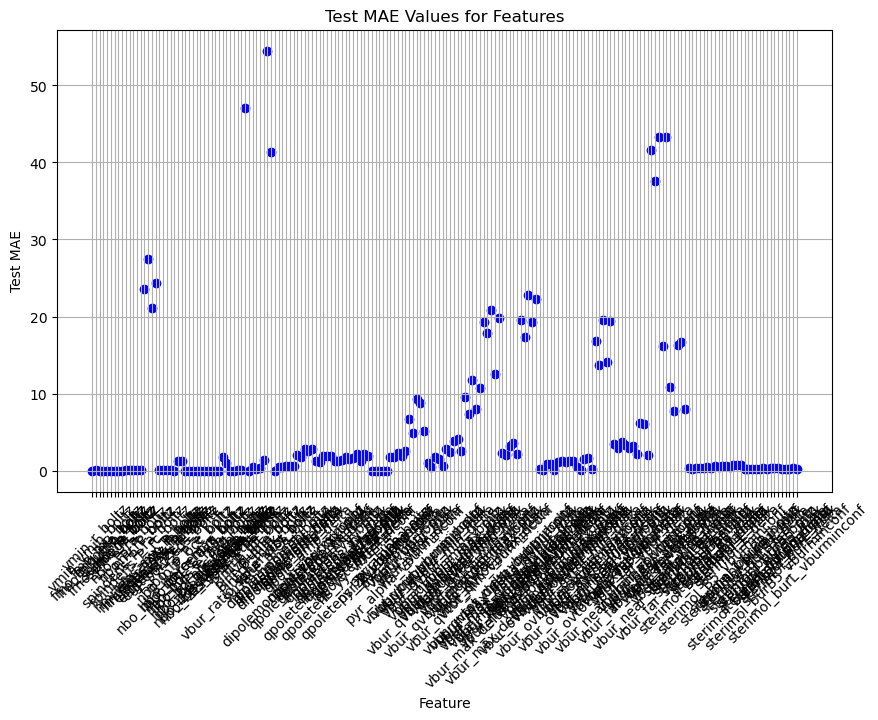

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV file
data = pd.read_csv('model_performance_xgb.csv')

# Scatter plot for RMSE
plt.figure(figsize=(10, 6))
plt.scatter(data['Feature'], data['Test MAE'], color='blue')
plt.title('Test MAE Values for Features')
plt.xlabel('Feature')
plt.ylabel('Test MAE')
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [33]:
data.head()

,Feature,Validation MAE,Test MAE,R²,Best Parameters
0,vmin_vmin_boltz,0.005532,0.005183,0.775107,"{'max_depth': 22, 'min_child_weight': 15, 'lea..."
1,vmin_r_boltz,0.030324,0.027003,0.660329,"{'max_depth': 11, 'min_child_weight': 3, 'lear..."
2,fmo_e_homo_boltz,0.007474,0.006890,0.775960,"{'max_depth': 11, 'min_child_weight': 8, 'lear..."
3,fmo_e_lumo_boltz,0.006593,0.006826,0.893662,"{'max_depth': 27, 'min_child_weight': 7, 'lear..."
4,fmo_mu_boltz,0.006256,0.005944,0.816443,"{'max_depth': 7, 'min_child_weight': 3, 'learn..."


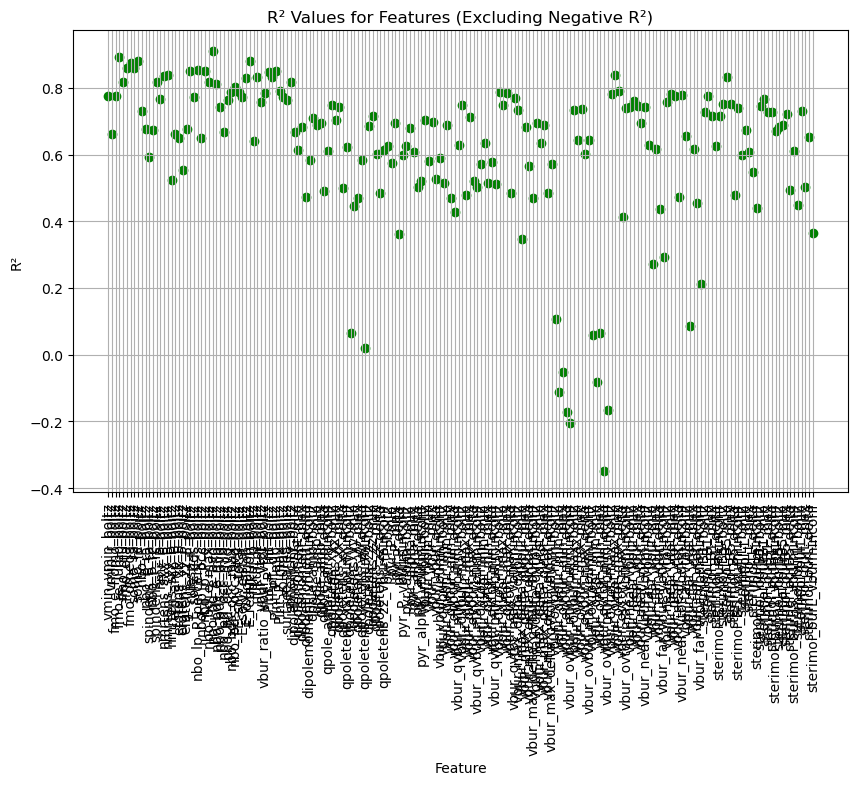

In [35]:
# Filter out rows with negative R²
filtered_data_r2 = data[data['R²'] >= -1000]
# Scatter plot for R²
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data_r2['Feature'], filtered_data_r2['R²'], color='green')
plt.title('R² Values for Features (Excluding Negative R²)')
plt.xlabel('Feature')
plt.ylabel('R²')
plt.xticks(rotation=90)
plt.grid()
plt.show()


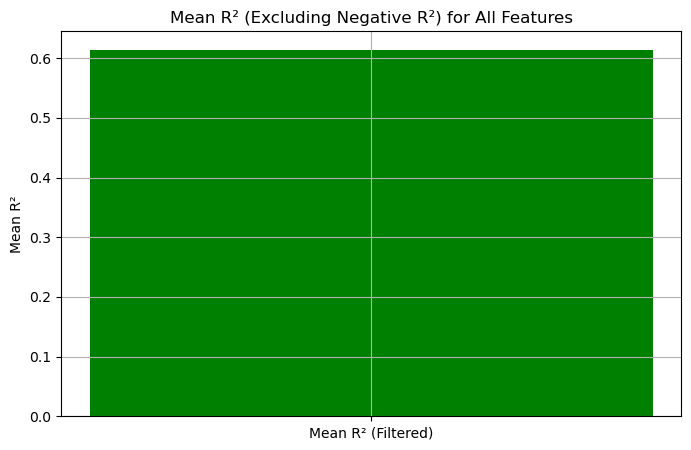

0.6144227760180923


In [37]:
mean_r2_filtered = filtered_data_r2['R²'].mean()

plt.figure(figsize=(8, 5))
plt.bar(['Mean R² (Filtered)'], [mean_r2_filtered], color='green')
plt.title('Mean R² (Excluding Negative R²) for All Features')
plt.ylabel('Mean R²')
plt.grid()
plt.show()
print(mean_r2_filtered)

In [39]:
tmean_r2 = data['R²'].mean()

plt.figure(figsize=(8, 5))
plt.bar(['Mean RMSE', 'Mean R²'], [mean_rmse, mean_r2], color=['blue', 'green'])
plt.title('Mean RMSE and R² for All Features')
plt.ylabel('Values')
plt.grid()
plt.show()
print(mean_r2)

NameError: name 'mean_rmse' is not defined

<Figure size 800x500 with 0 Axes>